In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

In [2]:
BASE_DIR = Path.cwd()

# If notebook is running from the notebooks folder
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print("Project:", BASE_DIR)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)

Project: c:\Users\rohit\OneDrive\Desktop\MajorProject\Data_Science_Projects\ecommerce-eda-sales-pipeline
Raw data: c:\Users\rohit\OneDrive\Desktop\MajorProject\Data_Science_Projects\ecommerce-eda-sales-pipeline\data\raw
Processed data: c:\Users\rohit\OneDrive\Desktop\MajorProject\Data_Science_Projects\ecommerce-eda-sales-pipeline\data\processed


In [3]:
orders = pd.read_csv(
    PROCESSED_DIR / "orders_clean.csv",
    parse_dates=[
        "order_date",
        "shipping_date",
        "delivery_date"
    ]
)

customers = pd.read_csv(
    PROCESSED_DIR / "customers_features.csv",
    parse_dates=[
        "signup_date",
        "last_purchase_date",
        "first_purchase_date"
    ]
)

products = pd.read_csv(
    RAW_DIR / "products.csv"
)

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)

Orders: (20000, 21)
Customers: (5000, 19)
Products: (300, 6)


## 3. Dataset Overview

In [4]:
orders.head()

,order_id,customer_id,order_date,order_status,payment_method,shipping_date,delivery_date,order_revenue,total_items,total_discount,customer_segment,city,age,gender,order_month,order_year,order_week,order_day,is_weekend,shipping_days,delivery_days
0,ORD000001,CUST01864,2025-09-13 17:15:29,Completed,UPI,2025-09-18 17:15:29,2025-09-25 17:15:29,554.59,1,0.00,Regular,Kolkata,41,Other,2025-09,2025,37,Saturday,True,5.00,12.00
1,ORD000002,CUST00420,2025-10-14 06:36:10,Returned,UPI,2025-10-17 06:36:10,2025-10-20 06:36:10,"4,255.71",3,192.16,VIP,Hyderabad,39,Male,2025-10,2025,42,Tuesday,False,3.00,6.00
2,ORD000003,CUST00624,2025-01-21 07:40:58,Completed,UPI,2025-01-24 07:40:58,2025-01-29 07:40:58,750.24,1,0.00,Regular,Mumbai,38,Male,2025-01,2025,4,Tuesday,False,3.00,8.00
3,ORD000004,CUST02737,2024-03-28 11:54:20,Completed,Debit Card,2024-04-01 11:54:20,2024-04-03 11:54:20,814.85,1,0.00,Regular,Chennai,29,Female,2024-03,2024,13,Thursday,False,4.00,6.00
4,ORD000005,CUST02570,2025-04-29 15:25:06,Completed,Net Banking,2025-05-04 15:25:06,2025-05-07 15:25:06,846.90,1,282.30,Regular,Bangalore,32,Male,2025-04,2025,18,Tuesday,False,5.00,8.00


In [5]:
customers.head()

,customer_id,customer_name,email,gender,age,city,customer_segment,signup_date,total_orders,total_revenue,average_order_value,total_items,last_purchase_date,first_purchase_date,days_since_last_purchase,customer_lifetime_value_proxy,purchase_lifetime_days,revenue_per_day_active,churn_risk
0,CUST00001,Aadhya Prashad,hritiknori@example.net,Female,35,Jaipur,Regular,2025-09-08,3.00,"17,092.00","5,697.33",13.00,2025-06-11 07:06:09,2024-11-14 12:36:54,203.00,"17,092.00",208.00,82.17,High Risk
1,CUST00002,Samaksh Narayanan,mitalimenon@example.org,Male,28,Mumbai,Regular,2024-02-10,3.00,"22,386.02","7,462.01",15.00,2025-06-24 21:51:12,2024-07-11 07:13:15,190.00,"22,386.02",348.00,64.33,High Risk
2,CUST00003,Sara Mohanty,kiaan71@example.org,Male,45,Kolkata,Regular,2024-01-07,3.00,"11,531.18","3,843.73",13.00,2024-08-04 19:53:57,2024-03-08 03:18:49,514.00,"11,531.18",149.00,77.39,High Risk
3,CUST00004,Kashvi Pau,sachi28@example.org,Male,21,Bangalore,Regular,2025-04-18,2.00,"9,602.21","4,801.10",7.00,2024-09-28 19:21:59,2024-02-28 00:22:57,459.00,"9,602.21",213.00,45.08,High Risk
4,CUST00005,Madhav Sibal,xgopal@example.net,Female,33,Lucknow,Premium,2026-04-20,3.00,"7,570.40","2,523.47",8.00,2024-12-01 22:18:40,2024-10-02 06:35:11,395.00,"7,570.40",60.00,126.17,High Risk


In [6]:
products.head()

,product_id,product_name,category,unit_price,cost_price,stock_quantity
0,PROD0001,Beauty Product 0001,Beauty,"1,029.53",713.88,78
1,PROD0002,Fashion Product 0002,Fashion,"1,362.04",701.29,78
2,PROD0003,Beauty Product 0003,Beauty,"1,225.95",724.64,39
3,PROD0004,Home Product 0004,Home,"2,505.19","1,616.71",21
4,PROD0005,Beauty Product 0005,Beauty,449.55,228.70,34


In [7]:
print("Orders columns:")
print(orders.columns.tolist())

print("\nCustomer columns:")
print(customers.columns.tolist())

print("\nProduct columns:")
print(products.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_date', 'order_status', 'payment_method', 'shipping_date', 'delivery_date', 'order_revenue', 'total_items', 'total_discount', 'customer_segment', 'city', 'age', 'gender', 'order_month', 'order_year', 'order_week', 'order_day', 'is_weekend', 'shipping_days', 'delivery_days']

Customer columns:
['customer_id', 'customer_name', 'email', 'gender', 'age', 'city', 'customer_segment', 'signup_date', 'total_orders', 'total_revenue', 'average_order_value', 'total_items', 'last_purchase_date', 'first_purchase_date', 'days_since_last_purchase', 'customer_lifetime_value_proxy', 'purchase_lifetime_days', 'revenue_per_day_active', 'churn_risk']

Product columns:
['product_id', 'product_name', 'category', 'unit_price', 'cost_price', 'stock_quantity']


In [8]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          20000 non-null  object        
 1   customer_id       20000 non-null  object        
 2   order_date        20000 non-null  datetime64[ns]
 3   order_status      20000 non-null  object        
 4   payment_method    20000 non-null  object        
 5   shipping_date     18629 non-null  datetime64[ns]
 6   delivery_date     18345 non-null  datetime64[ns]
 7   order_revenue     20000 non-null  float64       
 8   total_items       20000 non-null  int64         
 9   total_discount    20000 non-null  float64       
 10  customer_segment  20000 non-null  object        
 11  city              20000 non-null  object        
 12  age               20000 non-null  int64         
 13  gender            20000 non-null  object        
 14  order_month       2000

In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   customer_id                    5000 non-null   object        
 1   customer_name                  5000 non-null   object        
 2   email                          5000 non-null   object        
 3   gender                         5000 non-null   object        
 4   age                            5000 non-null   int64         
 5   city                           5000 non-null   object        
 6   customer_segment               5000 non-null   object        
 7   signup_date                    5000 non-null   datetime64[ns]
 8   total_orders                   5000 non-null   float64       
 9   total_revenue                  5000 non-null   float64       
 10  average_order_value            5000 non-null   float64       
 11  total_items      

## 4. Missing Value Analysis

In [10]:
orders.isnull().sum().sort_values(ascending=False)

delivery_date       1655
delivery_days       1655
shipping_days       1371
shipping_date       1371
order_id               0
payment_method         0
order_status           0
order_date             0
customer_id            0
total_discount         0
customer_segment       0
order_revenue          0
total_items            0
age                    0
city                   0
gender                 0
order_month            0
order_week             0
order_year             0
is_weekend             0
order_day              0
dtype: int64

In [11]:
customers.isnull().sum().sort_values(ascending=False)

first_purchase_date              343
last_purchase_date               343
customer_id                        0
email                              0
customer_name                      0
gender                             0
age                                0
signup_date                        0
total_orders                       0
city                               0
customer_segment                   0
average_order_value                0
total_revenue                      0
total_items                        0
days_since_last_purchase           0
customer_lifetime_value_proxy      0
purchase_lifetime_days             0
revenue_per_day_active             0
churn_risk                         0
dtype: int64

In [12]:
products.isnull().sum().sort_values(ascending=False)

product_id        0
product_name      0
category          0
unit_price        0
cost_price        0
stock_quantity    0
dtype: int64

## 5. Duplicate Analysis

In [13]:
print("Duplicate orders:", orders["order_id"].duplicated().sum())
print("Duplicate customers:", customers["customer_id"].duplicated().sum())
print("Duplicate products:", products["product_id"].duplicated().sum())

Duplicate orders: 0
Duplicate customers: 0
Duplicate products: 0


## 6. Descriptive Statistics

In [14]:
orders.describe()

,order_date,shipping_date,delivery_date,order_revenue,total_items,total_discount,age,order_year,order_week,shipping_days,delivery_days
count,20000,18629,18345,"20,000.00","20,000.00","20,000.00","20,000.00","20,000.00","20,000.00","18,629.00","18,345.00"
mean,2024-12-28 13:55:34.298450176,2024-12-31 05:02:46.412743424,2025-01-04 03:11:55.327282688,"3,321.91",2.86,306.00,34.19,"2,024.49",26.47,2.99,6.97
min,2024-01-01 00:38:36,2024-01-02 10:43:16,2024-01-04 05:30:29,171.70,1.00,0.00,18.00,"2,024.00",1.00,1.00,2.00
25%,2024-06-30 23:34:19.750000128,2024-07-03 18:53:37,2024-07-07 21:00:06,"1,255.88",1.00,59.58,27.00,"2,024.00",13.00,2.00,5.00
50%,2024-12-26 15:07:17,2024-12-28 17:29:36,2025-01-01 01:47:20,"2,470.15",2.00,187.53,34.00,"2,024.00",27.00,3.00,7.00
75%,2025-06-28 02:52:42.500000,2025-06-30 04:17:49,2025-07-04 10:31:22,"4,505.05",4.00,419.90,41.00,"2,025.00",39.00,4.00,9.00
max,2025-12-30 23:48:35,2026-01-04 19:38:46,2026-01-11 14:31:19,"29,083.04",13.00,"5,430.32",69.00,"2,025.00",52.00,5.00,12.00
std,NaN,NaN,NaN,"2,879.69",1.88,372.07,10.24,0.50,15.06,1.41,2.44


In [15]:
customers.describe()

,age,signup_date,total_orders,total_revenue,average_order_value,total_items,last_purchase_date,first_purchase_date,days_since_last_purchase,customer_lifetime_value_proxy,purchase_lifetime_days,revenue_per_day_active
count,"5,000.00",5000,"5,000.00","5,000.00","5,000.00","5,000.00",4657,4657,"5,000.00","5,000.00","5,000.00","5,000.00"
mean,33.82,2025-03-24 07:32:44.160000,3.65,"12,080.63","3,109.08",10.40,2025-06-12 21:39:08.730942720,2024-07-17 02:07:13.183379968,187.75,"12,080.63",307.89,587.55
min,18.00,2023-09-22 00:00:00,0.00,0.00,0.00,0.00,2024-01-02 09:24:00,2024-01-01 00:38:36,0.00,0.00,0.00,0.00
25%,26.00,2024-06-23 00:00:00,2.00,"4,035.51","1,874.39",4.00,2025-03-05 04:57:36,2024-02-27 01:27:16,42.00,"4,035.51",37.00,19.82
50%,33.00,2025-03-26 00:00:00,3.00,"8,868.98","2,896.74",8.00,2025-08-05 15:26:29,2024-05-23 12:59:45,133.00,"8,868.98",321.00,37.54
75%,41.00,2025-12-15 00:00:00,5.00,"15,861.09","4,053.67",14.00,2025-11-03 10:43:48,2024-10-20 19:50:08,288.00,"15,861.09",520.00,81.48
max,69.00,2026-09-21 00:00:00,77.00,"264,295.37","17,012.68",228.00,2025-12-30 23:48:35,2025-12-30 14:57:10,729.00,"264,295.37",725.00,"17,012.68"
std,10.14,NaN,3.90,"13,826.65","1,999.99",11.54,NaN,NaN,178.13,"13,826.65",236.13,"1,700.00"


## 7. Completed Orders

For revenue analysis, only completed orders are considered.

In [16]:
completed = orders[
    orders['order_status'] == 'Completed'
].copy()

print('Total orders:', len(orders))
print("Completed orders:", len(completed))

Total orders: 20000
Completed orders: 18252


## 8. Key Business KPIs

In [17]:
total_orders = orders['order_id'].nunique()

completed_orders = completed['order_id'].nunique()

total_revenue = completed['order_revenue'].sum()

average_order_value = completed['order_revenue'].mean()

total_customers = customers['customer_id'].nunique()

high_risk_customers = (
    customers['churn_risk'] == 'High Risk'
).sum()

print(f"Total Orders: {total_orders:,}")
print(f"Completed Orders: {completed_orders:,}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"Average Order Value: ₹{average_order_value:,.2f}")
print(f"Total Customers: {total_customers:,}")
print(f"High Risk Customers: {high_risk_customers:,}")

Total Orders: 20,000
Completed Orders: 18,252
Total Revenue: ₹60,403,131.99
Average Order Value: ₹3,309.40
Total Customers: 5,000
High Risk Customers: 2,020


## 9. Order Status Analysis

In [18]:
order_status = orders['order_status'].value_counts()

order_status

order_status
Completed    18252
Pending        764
Cancelled      607
Returned       377
Name: count, dtype: int64

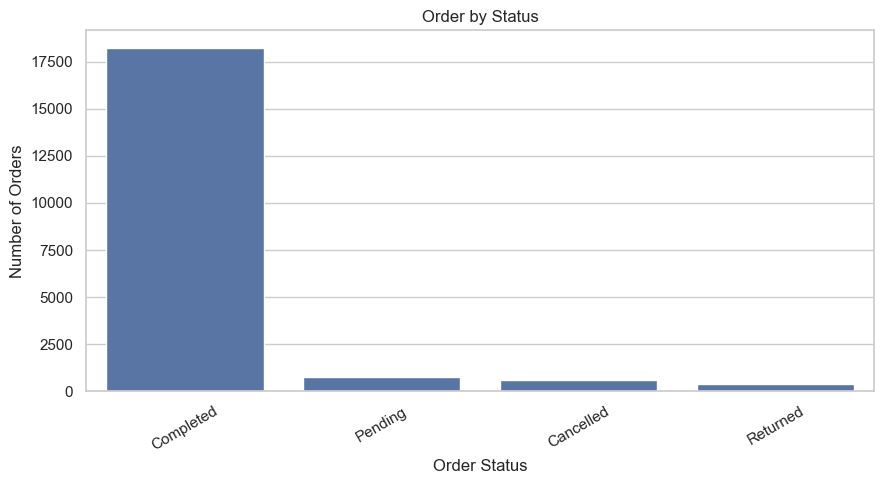

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=order_status.index,
    y=order_status.values
)

plt.title('Order by Status')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 10. Monthly Revenue Trend

In [20]:
monthly_revenue = (
    completed.assign(
        month = completed['order_date']
        .dt.to_period('M')
        .dt.to_timestamp()
    )
    .groupby('month', as_index=False)['order_revenue']
    .sum()
)

monthly_revenue.head()

,month,order_revenue
0,2024-01-01,"2,769,678.58"
1,2024-02-01,"2,293,677.17"
2,2024-03-01,"2,730,671.26"
3,2024-04-01,"2,594,257.68"
4,2024-05-01,"2,466,478.48"


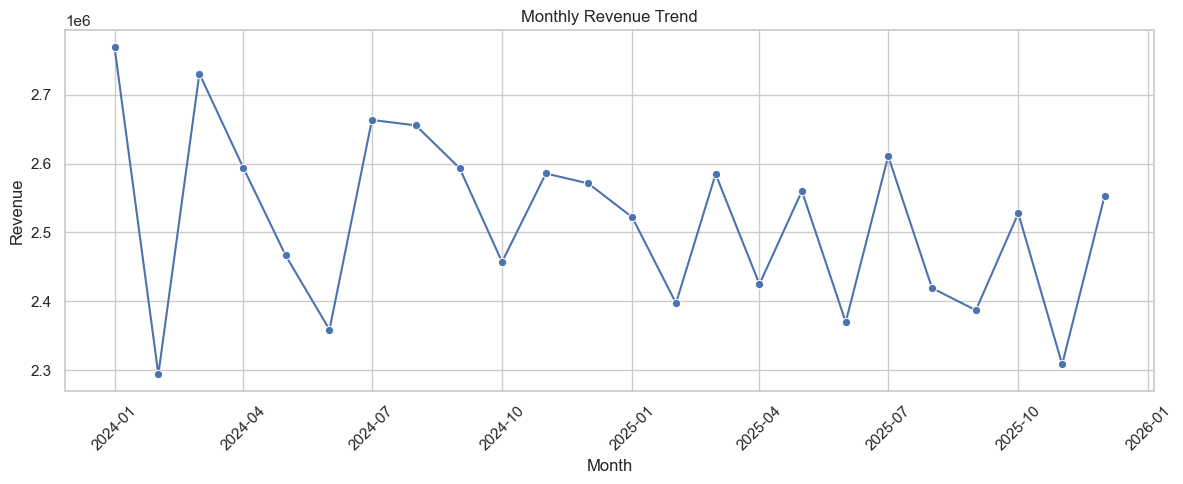

In [21]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_revenue,
    x="month",
    y="order_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 11. Monthly Order Volume

In [22]:
monthly_orders = (
    orders
    .assign(
        month=orders["order_date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .groupby("month")["order_id"]
    .nunique()
)

monthly_orders.head()

month
2024-01-01    865
2024-02-01    778
2024-03-01    887
2024-04-01    832
2024-05-01    811
Name: order_id, dtype: int64

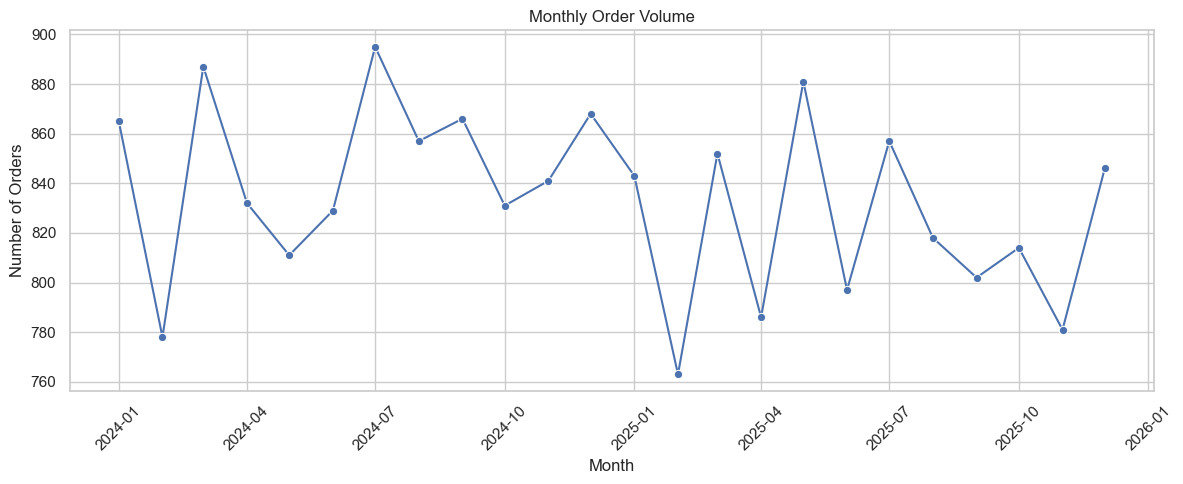

In [23]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    x=monthly_orders.index,
    y=monthly_orders.values,
    marker="o"
)

plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 12. Order Revenue Distribution

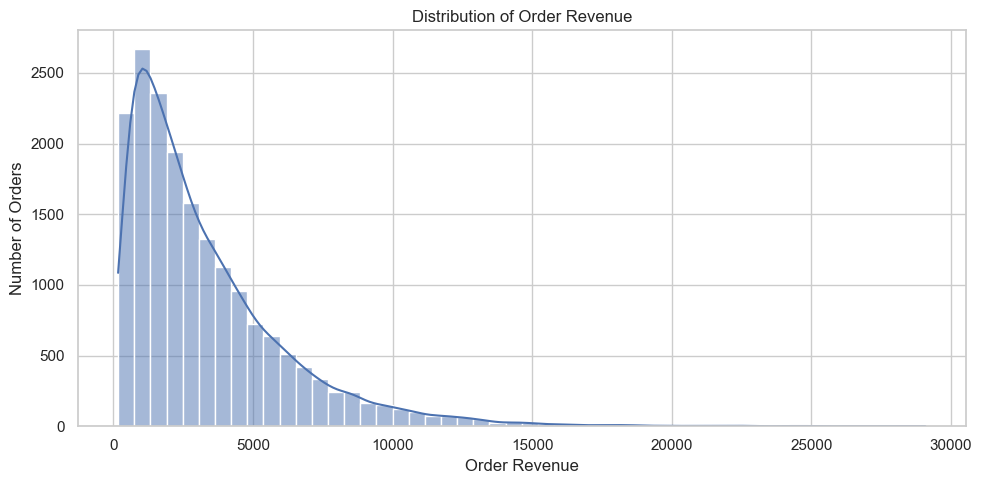

In [24]:
plt.figure(figsize=(10, 5))

sns.histplot(
    completed["order_revenue"],
    bins=50,
    kde=True
)

plt.title("Distribution of Order Revenue")
plt.xlabel("Order Revenue")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## 13. Customer Revenue Distribution

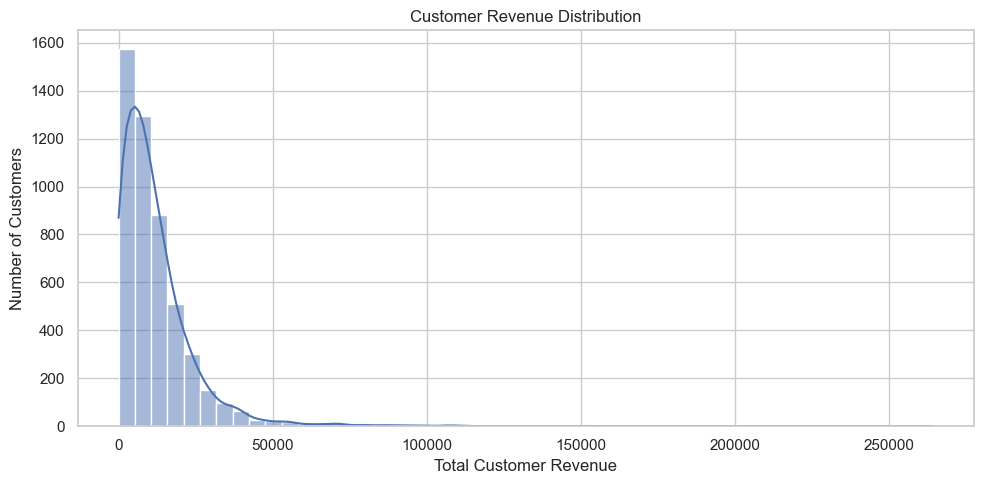

In [25]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customers["total_revenue"],
    bins=50,
    kde=True
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 14. Revenue by Customer Segment

In [26]:
segment_revenue = (
    customers.groupby('customer_segment')['total_revenue']
    .sum().sort_values(ascending=False)
)

segment_revenue

customer_segment
Regular   42,591,471.21
Premium   14,680,909.69
VIP        3,130,751.09
Name: total_revenue, dtype: float64

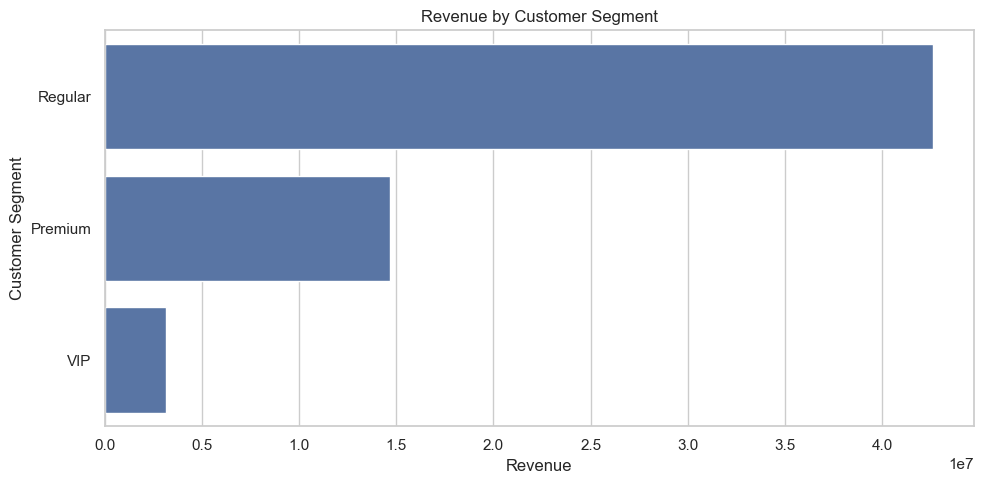

In [27]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=segment_revenue.values,
    y=segment_revenue.index
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## 15. Customer Churn-Risk Analysis

Churn risk is a rule-based classification created during ETL:

- 180+ days → High Risk
- 90+ days → At Risk
- 60+ days → Watch
- Otherwise → Active

In [28]:
risk_counts = (
    customers["churn_risk"]
    .value_counts()
    .reindex(
        ["Active", "Watch", "At Risk", "High Risk"]
    )
    .fillna(0)
)

risk_counts

churn_risk
Active       1527
Watch         455
At Risk       998
High Risk    2020
Name: count, dtype: int64

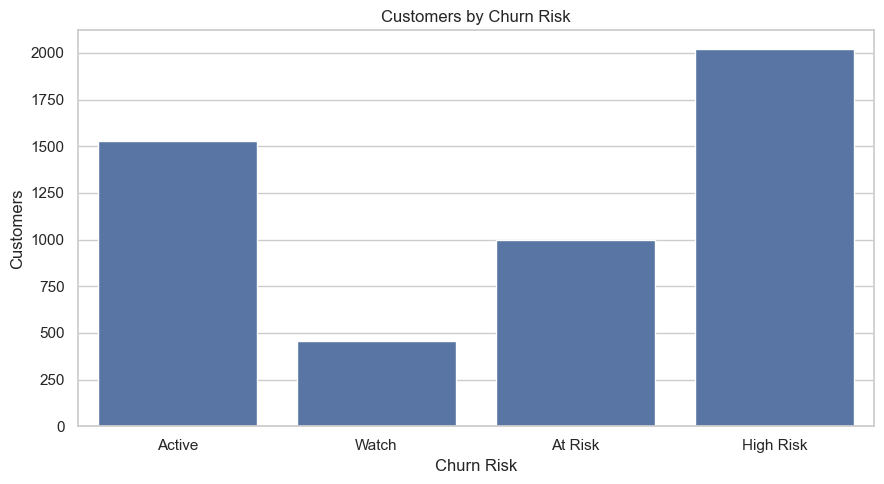

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=risk_counts.index,
    y=risk_counts.values
)

plt.title("Customers by Churn Risk")
plt.xlabel("Churn Risk")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

In [30]:
risk_summary = (
    customers
    .groupby("churn_risk")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        average_revenue=("total_revenue", "mean"),
        average_orders=("total_orders", "mean")
    )
    .reindex(
        ["Active", "Watch", "At Risk", "High Risk"]
    )
)

risk_summary

,customers,revenue,average_revenue,average_orders
churn_risk,,,,
Active,1527,"23,232,117.92","15,214.22",4.62
Watch,455,"6,909,923.23","15,186.64",4.53
At Risk,998,"13,164,747.51","13,191.13",3.99
High Risk,2020,"17,096,343.33","8,463.54",2.55


## 16. Top 10 Customers by Revenue

In [31]:
top_customers = (
    customers[
        [
        'customer_id',
        'customer_name',
        'total_orders',
        'total_revenue',
        'churn_risk'
        ]
    ].sort_values(
        'total_revenue',
        ascending=False
    )
    .head(10)
)

top_customers

,customer_id,customer_name,total_orders,total_revenue,churn_risk
4137,CUST04138,Anika Bakshi,77.00,"264,295.37",Active
1352,CUST01353,Mekhala Dutta,71.00,"258,815.76",Active
232,CUST00233,Isaiah Rajagopalan,68.00,"206,261.52",Active
209,CUST00210,Mugdha Zacharia,57.00,"169,083.68",Active
3832,CUST03833,Unnati Chanda,54.00,"155,334.97",Active
3692,CUST03693,Hardik Anand,44.00,"150,885.06",Active
2880,CUST02881,Hritik Gokhale,34.00,"114,674.58",Active
3857,CUST03858,Keya Kata,28.00,"110,270.61",Active
4172,CUST04173,Unni Aurora,28.00,"109,132.06",Active
397,CUST00398,Nachiket Kaul,21.00,"106,932.07",Active


## 17. Product Category Performance

In [32]:
order_items = pd.read_csv(
    RAW_DIR / "order_items.csv"
)

order_items["quantity"] = pd.to_numeric(
    order_items["quantity"],
    errors="coerce"
)

order_items["unit_price"] = pd.to_numeric(
    order_items["unit_price"],
    errors="coerce"
)

order_items["discount_percent"] = pd.to_numeric(
    order_items["discount_percent"],
    errors="coerce"
).fillna(0)

order_items["net_amount"] = (
    order_items["quantity"]
    * order_items["unit_price"]
    * (1 - order_items["discount_percent"] / 100)
)

order_items.head()

,order_item_id,order_id,product_id,quantity,unit_price,discount_percent,net_amount
0,ITEM0000001,ORD000001,PROD0157,1,554.59,0,554.59
1,ITEM0000002,ORD000002,PROD0025,2,"1,921.63",5,"3,651.10"
2,ITEM0000003,ORD000002,PROD0230,1,604.61,0,604.61
3,ITEM0000004,ORD000003,PROD0174,1,750.24,0,750.24
4,ITEM0000005,ORD000004,PROD0075,1,814.85,0,814.85


In [33]:
category_data = order_items.merge(
    products[
        [
            "product_id",
            "category"
        ]
    ],
    on="product_id",
    how="left"
)

In [36]:
category_summary = (
    category_data
    .groupby("category")
    .agg(
        revenue=("net_amount", "sum"),
        items_sold=("quantity", "sum")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
)

category_summary

,revenue,items_sold
category,,
Fashion,"16,858,734.91",14805
Home,"13,270,129.54",11178
Electronics,"12,255,418.39",11065
Beauty,"10,477,710.17",8194
Sports,"8,031,527.83",6651
Books,"5,544,667.94",5259


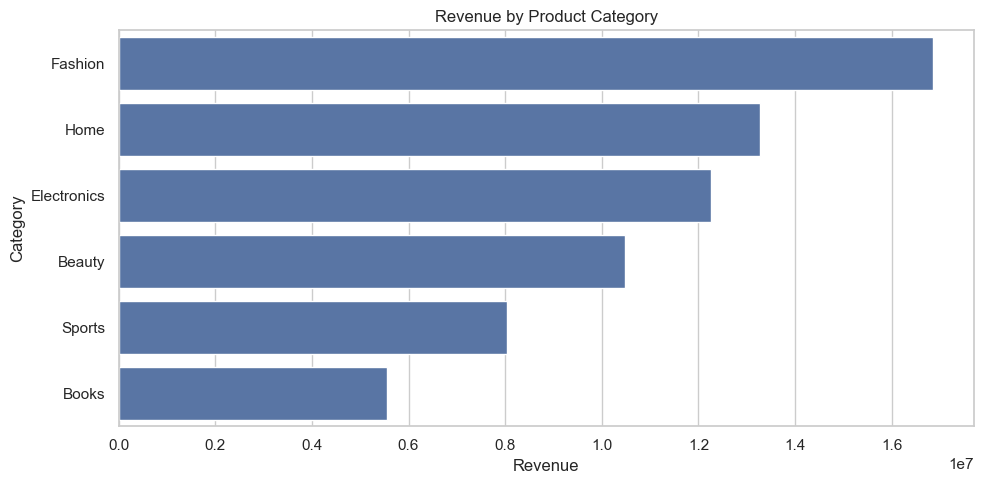

In [37]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_summary.reset_index(),
    x="revenue",
    y="category"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 18. Delivery Performance

In [38]:
orders[
    [
        "shipping_days",
        "delivery_days"
    ]
].describe()

,shipping_days,delivery_days
count,"18,629.00","18,345.00"
mean,2.99,6.97
std,1.41,2.44
min,1.00,2.00
25%,2.00,5.00
50%,3.00,7.00
75%,4.00,9.00
max,5.00,12.00


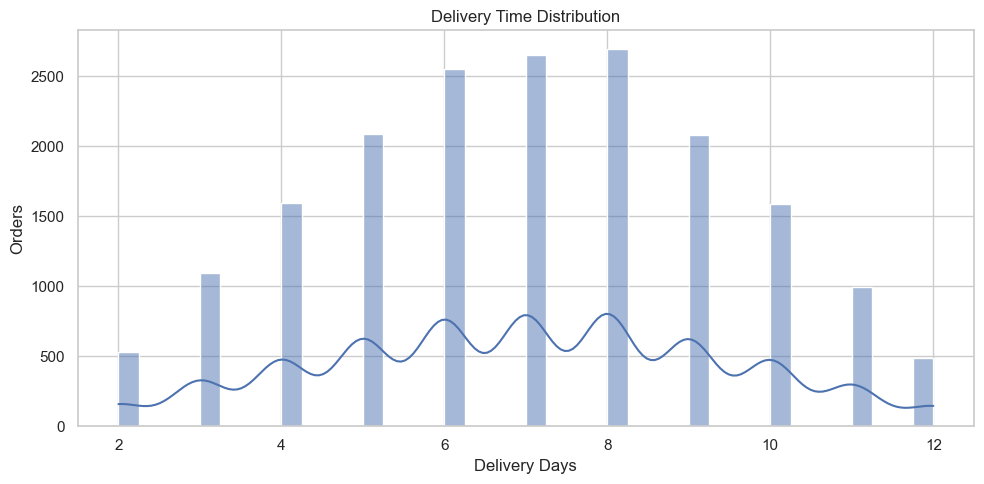

In [39]:
plt.figure(figsize=(10, 5))

sns.histplot(
    orders["delivery_days"].dropna(),
    bins=40,
    kde=True
)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Orders")

plt.tight_layout()
plt.show()

## 19. Customer Feature Correlation

In [ ]:
numeric_columns = [
    "total_orders",
    "total_revenue",
    "average_order_value",
    "total_items",
    "days_since_last_purchase",
    "purchase_lifetime_days",
    "revenue_per_day_active"
]

correlation = customers[numeric_columns].corr()

correlation

,total_orders,total_revenue,average_order_value,total_items,days_since_last_purchase,purchase_lifetime_days,revenue_per_day_active
total_orders,1.00,0.92,0.09,0.95,-0.25,0.58,-0.21
total_revenue,0.92,1.00,0.37,0.97,-0.23,0.54,-0.13
average_order_value,0.09,0.37,1.00,0.25,0.14,0.13,0.46
total_items,0.95,0.97,0.25,1.00,-0.24,0.55,-0.16
days_since_last_purchase,-0.25,-0.23,0.14,-0.24,1.00,-0.48,0.31
purchase_lifetime_days,0.58,0.54,0.13,0.55,-0.48,1.00,-0.42
revenue_per_day_active,-0.21,-0.13,0.46,-0.16,0.31,-0.42,1.00


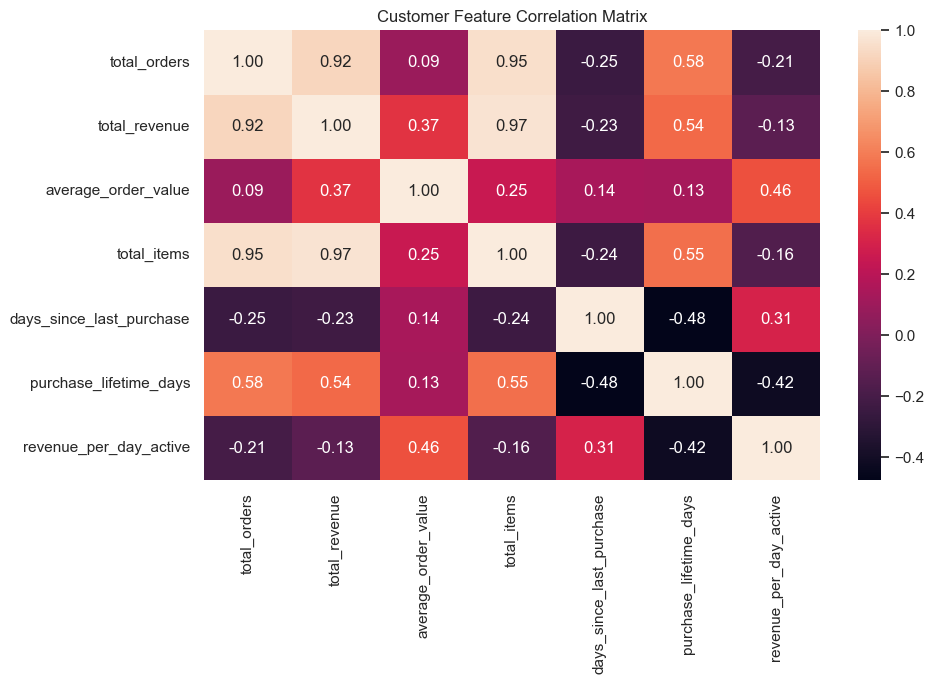

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Customer Feature Correlation Matrix")

plt.tight_layout()
plt.show()

## 20. Key Business Observations

In [ ]:
top_segment = segment_revenue.idxmax()


largest_risk_group = risk_counts.idxmax()

print("KEY BUSINESS OBSERVATIONS")
print("=" * 40)

print(
    f"Highest revenue customer segment: "
    f"{top_segment}"
)


print(
    f"Largest customer risk group: "
    f"{largest_risk_group}"
)

print(
    f"Total completed revenue: "
    f"₹{total_revenue:,.2f}"
)

print(
    f"Average completed order value: "
    f"₹{average_order_value:,.2f}"
)

KEY BUSINESS OBSERVATIONS
Highest revenue customer segment: Regular
Largest customer risk group: High Risk
Total completed revenue: ₹60,403,131.99
Average completed order value: ₹3,309.40


## 21. Conclusion

### Key Findings

- Analyzed overall business performance using key revenue, order, and customer KPIs.
- Identified monthly revenue and order trends to understand business performance over time.
- Compared customer segments based on their revenue contribution.
- Analyzed churn-risk groups to identify customers requiring attention.
- Evaluated product categories based on revenue and sales volume.
- Examined delivery performance to understand order fulfillment patterns.
- Used visualizations to identify important patterns and support data-driven business insights.

### Summary

This analysis provides a focused view of the e-commerce business by combining
revenue, customer, product, churn-risk, and delivery analysis.

The findings from this notebook can be used to understand customer behavior,
identify business opportunities, and support data-driven decision-making.